In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import platform
import matplotlib.pyplot as plt
import math


# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
    
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [3]:
df = pd.read_csv("data/Courses.csv")

In [4]:
df.shape

(641138, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 641138 entries, 0 to 641137
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   index              641138 non-null  int64  
 1   course_id          641138 non-null  object 
 2   userid_DI          641138 non-null  object 
 3   registered         641138 non-null  int64  
 4   viewed             641138 non-null  int64  
 5   explored           641138 non-null  int64  
 6   certified          641138 non-null  int64  
 7   final_cc_cname_DI  641138 non-null  object 
 8   LoE_DI             535130 non-null  object 
 9   YoB                544533 non-null  float64
 10  gender             554332 non-null  object 
 11  grade              592766 non-null  object 
 12  start_time_DI      641138 non-null  object 
 13  last_event_DI      462184 non-null  object 
 14  nevents            441987 non-null  float64
 15  ndays_act          478395 non-null  float64
 16  np

In [6]:
### 컬럼명 소문자화
df.columns = df.columns.str.lower()
print(df.columns)

Index(['index', 'course_id', 'userid_di', 'registered', 'viewed', 'explored',
       'certified', 'final_cc_cname_di', 'loe_di', 'yob', 'gender', 'grade',
       'start_time_di', 'last_event_di', 'nevents', 'ndays_act', 'nplay_video',
       'nchapters', 'nforum_posts', 'roles', 'incomplete_flag'],
      dtype='object')


In [7]:
### 데이터 타입 변경
cols = ['start_time_di','last_event_di']

for col in cols:
    df[col] = pd.to_datetime(df[col], format='%Y-%m-%d', errors='coerce')

In [8]:
### 파생컬럼 생성

## 남여 구분
df['is_female'] = (df['gender'] == 'f').astype(int)

## 수강당시 나이 계산
start_year = df['start_time_di'].dt.year
df['age_at_enrollment'] = start_year - df['yob']

## 수강당시 연령대
df['age_group'] = (df['age_at_enrollment'] // 10) * 10

데이터 분포 확인

In [9]:
df.describe()

,index,registered,viewed,explored,certified,yob,start_time_di,last_event_di,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag,is_female,age_at_enrollment,age_group
count,641138.000000,641138.0,641138.000000,641138.000000,641138.000000,544533.000000,641138,462184,441987.000000,478395.000000,183608.000000,382385.000000,641138.000000,0.0,100161.0,641138.000000,544533.000000,544533.000000
mean,320568.500000,1.0,0.624299,0.061899,0.027587,1985.253279,2013-01-02 16:07:19.273916672,2013-03-11 02:44:13.343257344,431.008018,5.710254,114.844173,3.634423,0.018968,NaN,1.0,0.222721,27.274624,22.944909
min,0.000000,1.0,0.000000,0.000000,0.000000,1931.000000,2012-07-23 00:00:00,2012-07-24 00:00:00,1.000000,1.000000,1.000000,1.000000,0.000000,NaN,1.0,0.000000,0.000000,0.000000
25%,160284.250000,1.0,0.000000,0.000000,0.000000,1982.000000,2012-10-01 00:00:00,2012-12-25 00:00:00,3.000000,1.000000,5.000000,1.000000,0.000000,NaN,1.0,0.000000,21.000000,20.000000
50%,320568.500000,1.0,1.000000,0.000000,0.000000,1988.000000,2013-01-10 00:00:00,2013-03-17 00:00:00,24.000000,2.000000,18.000000,2.000000,0.000000,NaN,1.0,0.000000,25.000000,20.000000
75%,480852.750000,1.0,1.000000,0.000000,0.000000,1991.000000,2013-03-10 00:00:00,2013-05-29 00:00:00,158.000000,4.000000,73.000000,4.000000,0.000000,NaN,1.0,0.000000,31.000000,30.000000
max,641137.000000,1.0,1.000000,1.000000,1.000000,2013.000000,2013-09-08 00:00:00,2013-11-17 00:00:00,197757.000000,205.000000,98517.000000,48.000000,20.000000,NaN,1.0,1.000000,82.000000,80.000000
std,185080.742781,0.0,0.484304,0.240973,0.163786,8.891814,NaN,NaN,1516.116057,11.866471,426.996844,4.490987,0.229539,NaN,0.0,0.416073,8.894466,9.271617


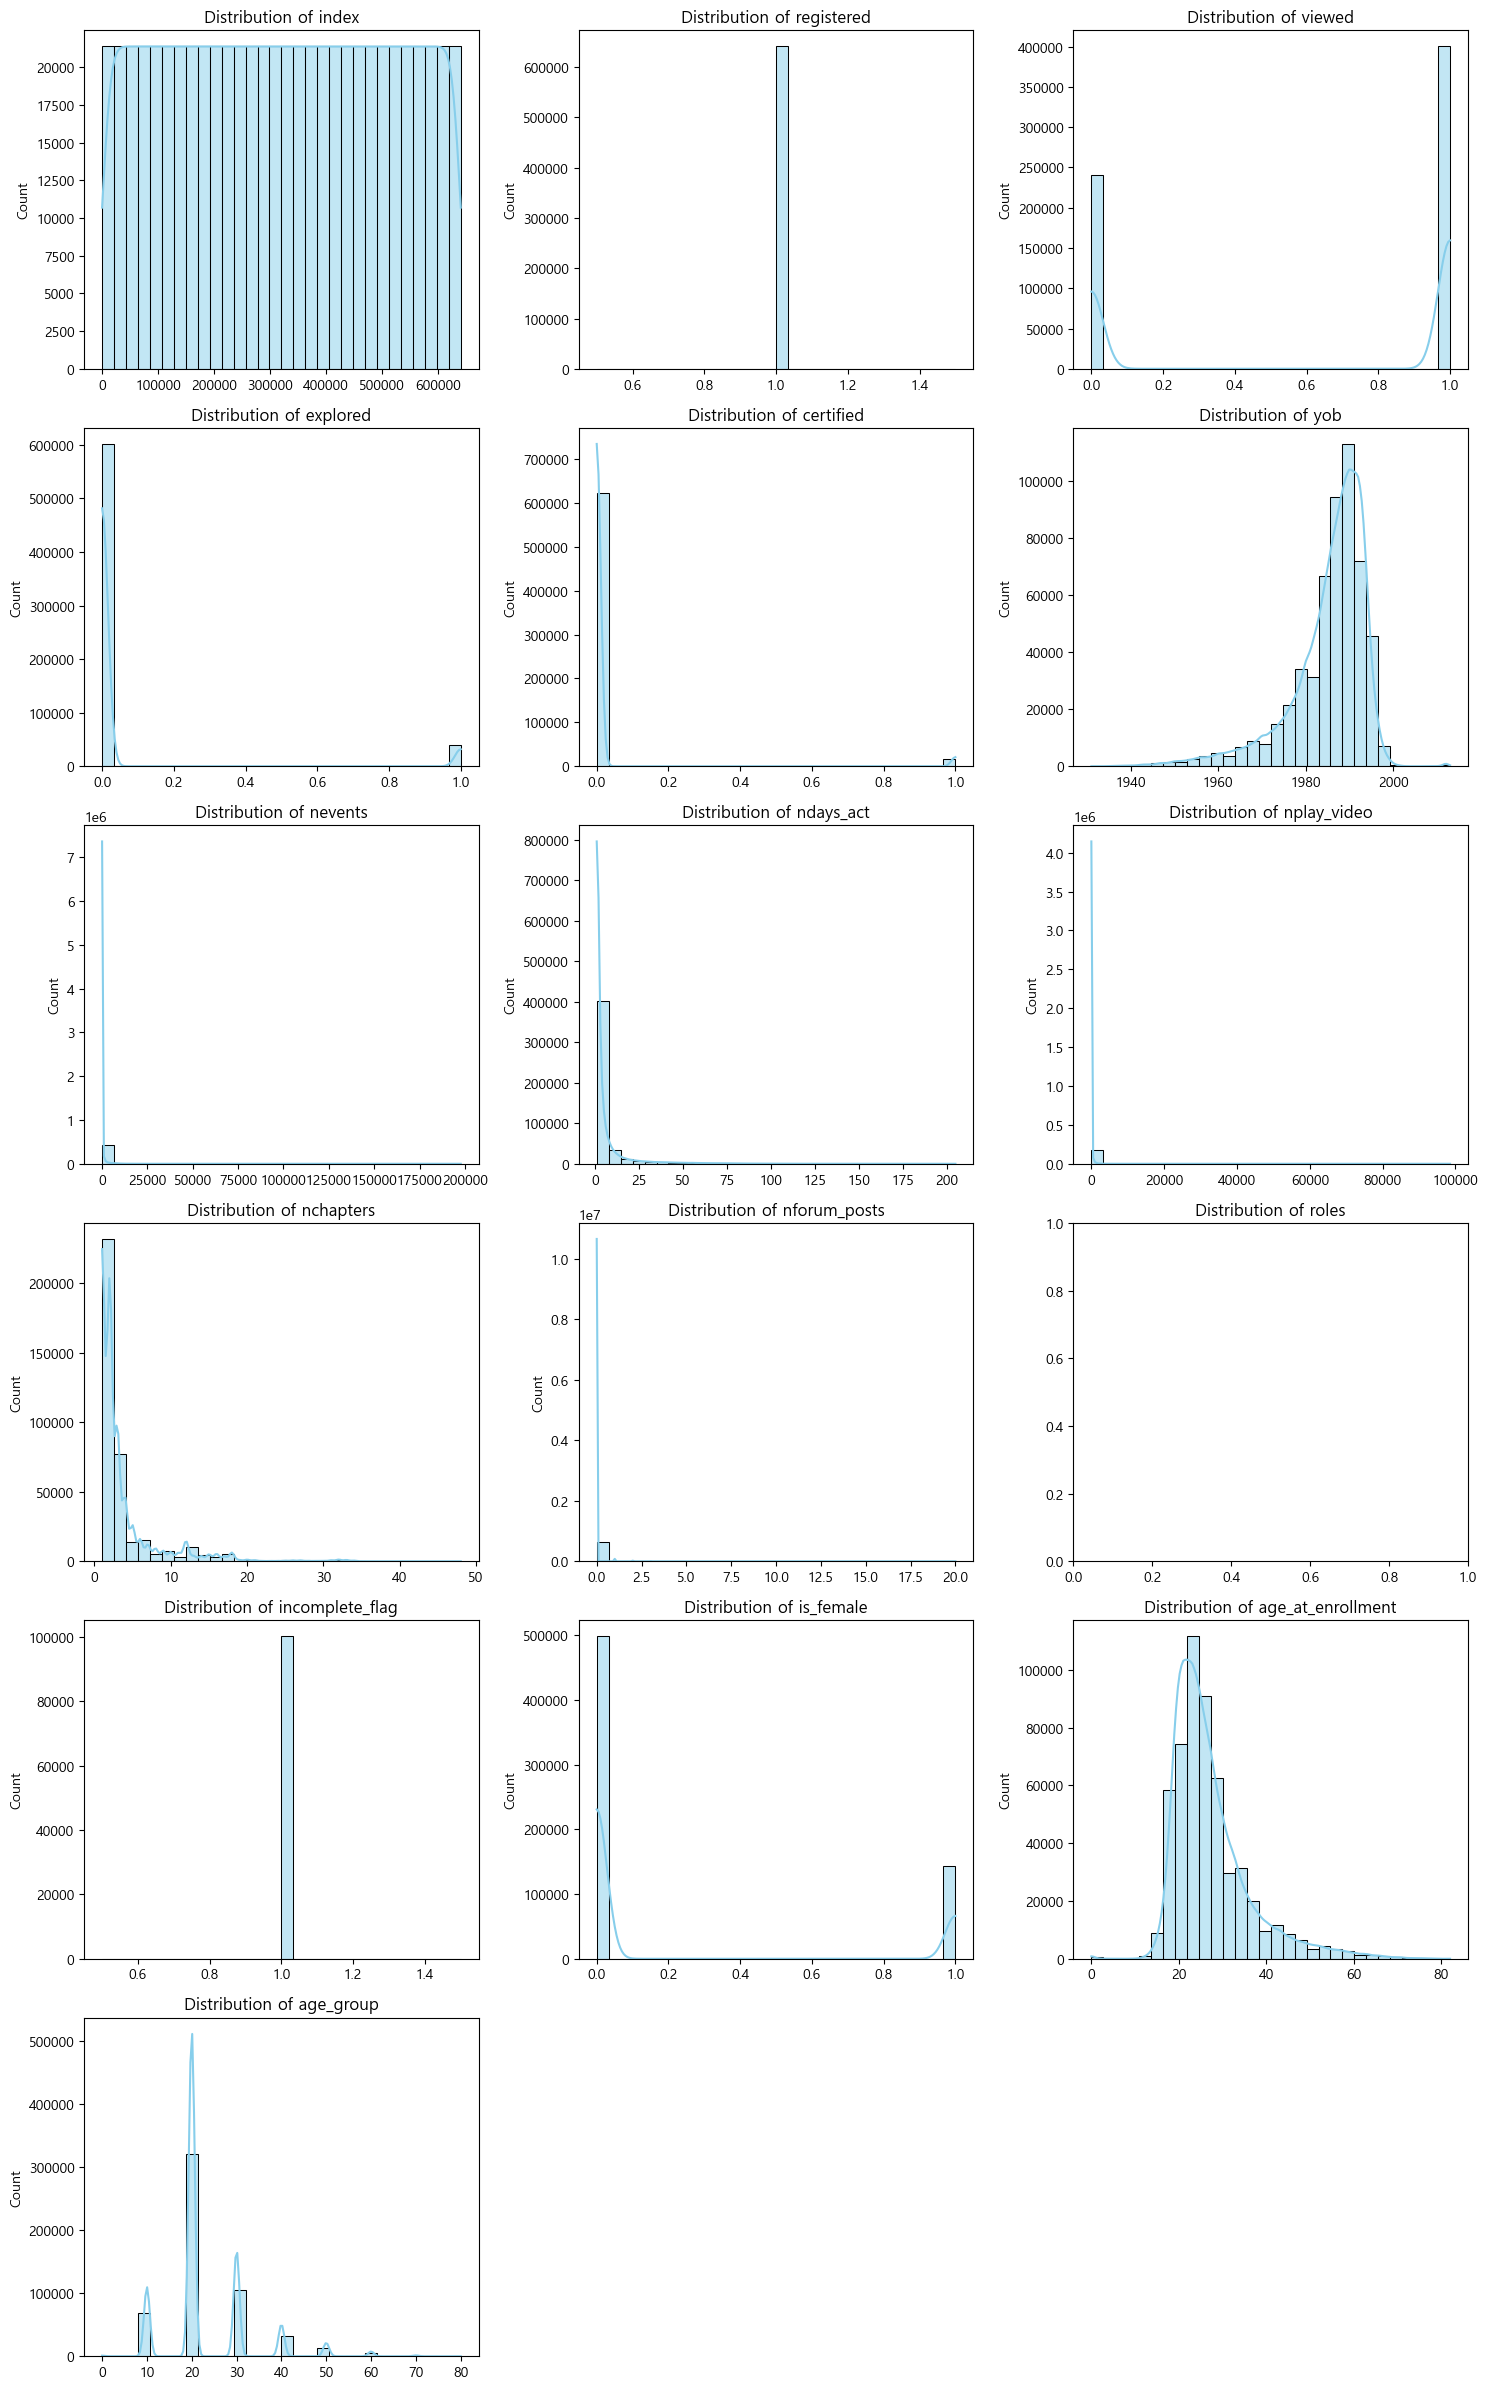

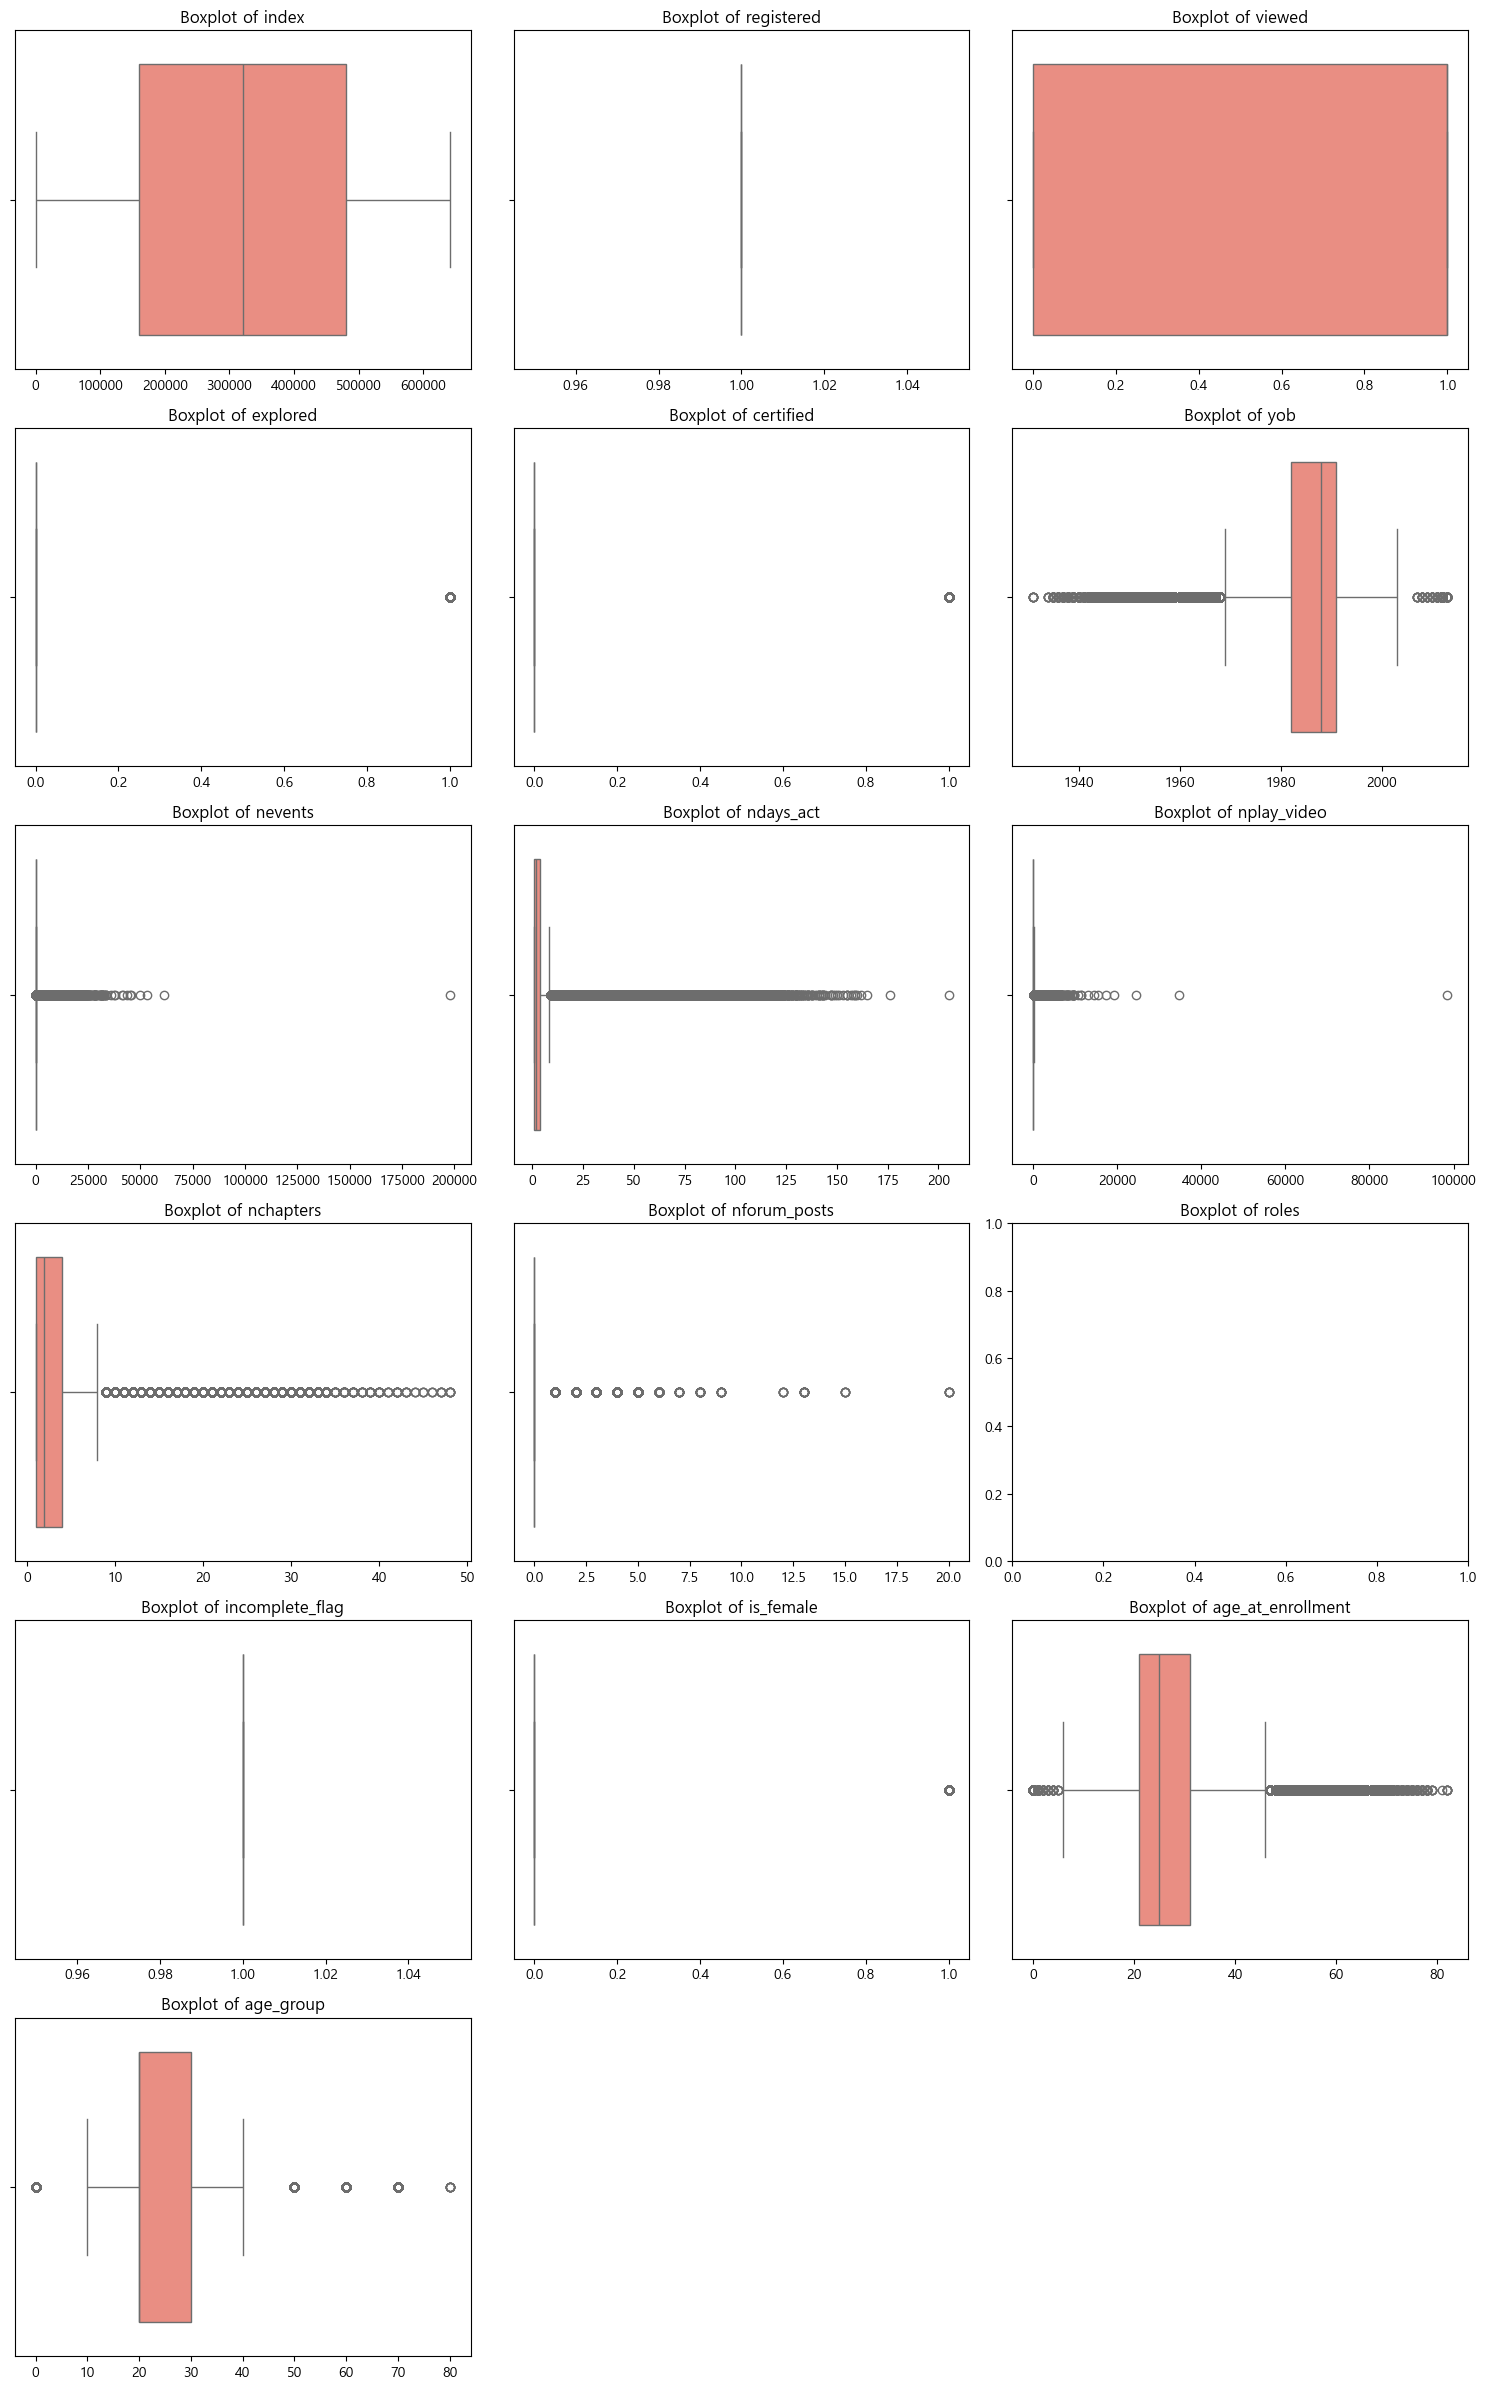

In [10]:
# 1. 수치형 컬럼만 자동 선택 (int64, float64)
numeric_cols = df.select_dtypes(include=['number']).columns
n_cols = len(numeric_cols)

# 2. 레이아웃 설정 (한 행에 3개씩 배치)
cols_per_row = 3
n_rows = math.ceil(n_cols / cols_per_row)

# --- [히스토그램 & KDE 분포 확인] ---
plt.figure(figsize=(15, n_rows * 4))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, cols_per_row, i)
    # kde=True는 부드러운 밀도 곡선을 추가해줍니다.
    sns.histplot(df[col].dropna(), kde=True, color='skyblue', bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel('')

plt.tight_layout()
plt.show()

# --- [박스플롯 이상치 확인] ---
plt.figure(figsize=(15, n_rows * 4))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, cols_per_row, i)
    sns.boxplot(x=df[col].dropna(), color='salmon')
    plt.title(f'Boxplot of {col}')
    plt.xlabel('')

plt.tight_layout()
plt.show()

In [11]:
def get_data_quality_report(df):
    report = []
    
    for col in df.columns:
        # 0. 데이터 타입 확인
        dtype = df[col].dtype

        # 1. 결측치 계산
        null_count = df[col].isnull().sum()
        null_pct = (null_count / len(df)) * 100
        
        # 2. 이상치 계산 (수치형 변수만 해당)
        outlier_count = 0
        outlier_pct = 0
        
        if df[col].dtype in ['float64', 'int64']:
            # IQR 방식 적용
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
            outlier_pct = (outlier_count / len(df)) * 100
            
        report.append({
            'Column': col,
            'DateType': dtype,
            'Total Rows': len(df),
            'Null Count': null_count,
            'Null (%)': round(null_pct, 2),
            'Outlier Count': outlier_count,
            'Outlier (%)': round(outlier_pct, 2)
        })
    
    return pd.DataFrame(report)

# 보고서 출력
quality_report = get_data_quality_report(df)
display(quality_report)

,Column,DateType,Total Rows,Null Count,Null (%),Outlier Count,Outlier (%)
0,index,int64,641138,0,0.00,0,0.00
1,course_id,object,641138,0,0.00,0,0.00
2,userid_di,object,641138,0,0.00,0,0.00
3,registered,int64,641138,0,0.00,0,0.00
4,viewed,int64,641138,0,0.00,0,0.00
5,explored,int64,641138,0,0.00,39686,6.19
6,certified,int64,641138,0,0.00,17687,2.76
7,final_cc_cname_di,object,641138,0,0.00,0,0.00
8,loe_di,object,641138,106008,16.53,0,0.00
9,yob,float64,641138,96605,15.07,32600,5.08


index (행 인덱스)
=> 의미 x

registered (등록 여부)
=> 모든 값 1 --> 데이터 내 모든 회원 등록 상태

roles (사용자 역할)
=> 결측치 100%

incomplete_flag (불완전 데이터 관련 플래그)
=> 결측치 84.38% --> 유용한지 모르겠음


===> 컬럼 제거
-----------------------------------------------------------
yob (출생연도)
=> unknown 처리 (가입 시 미입력 고려)
=> 중앙값 대체 (이상치 영향 적음)
=> 극단치 (0~18세 미만 혹은 70대 이상?) 제거 <-- 기준은 회의 필요

gender (성별)
=> unknown 처리 (가입 시 미입력 고려)
=> 최빈값 대체 (-> 편향 심해질 수 있음) <-- 안하는게 좋을 듯?

loe_di (학력 수준)
=> unknown 처리 (가입 시 미입력 고려)


===> 결측 여부를 확인하는 파생컬럼 생성?
--------------------------------------------------------------
last_event_di (마지막 활동일)
=> nan값 = 미활동 처리?

nevents (전체 이벤트 수(클릭, 행동 등)), ndays_act(실제 활동 일수), nplay_video(영상 재생 수), nchapters(탐색한 챕터 수)
=> nan값 = 미활동 처리? --> 0으로 대체


===> 중도 이탈 여부 확인 파생컬럼 생성?

In [12]:
df1 = df[df['gender'].isna()]
print(df1['loe_di'].value_counts())
print(df1['yob'].value_counts())

df2 = df[df['gender'] == 'o']
print(df2['loe_di'].value_counts())
print(df2['yob'].value_counts())
print(df2['userid_di'].value_counts())

loe_di
Bachelor's             480
Secondary              326
Master's               291
Doctorate               61
Less than Secondary     25
Name: count, dtype: int64
Series([], Name: count, dtype: int64)
loe_di
Bachelor's    5
Name: count, dtype: int64
yob
1988.0    5
Name: count, dtype: int64
userid_di
MHxPC130374549    1
MHxPC130496790    1
MHxPC130169870    1
MHxPC130069096    1
MHxPC130484845    1
MHxPC130002011    1
MHxPC130490398    1
MHxPC130508245    1
MHxPC130393703    1
MHxPC130313382    1
MHxPC130083224    1
MHxPC130450391    1
MHxPC130423269    1
MHxPC130232181    1
MHxPC130408177    1
MHxPC130453690    1
MHxPC130249332    1
Name: count, dtype: int64


In [13]:
df.groupby('course_id')['gender'].apply(lambda x:x.isna().sum())

course_id
HarvardX/CB22x/2013_Spring      3862
HarvardX/CS50x/2012            17195
HarvardX/ER22x/2013_Spring      6182
HarvardX/PH207x/2012_Fall       2759
HarvardX/PH278x/2013_Spring     2963
MITx/14.73x/2013_Spring         2792
MITx/2.01x/2013_Spring          1412
MITx/3.091x/2012_Fall           2634
MITx/3.091x/2013_Spring         1609
MITx/6.002x/2012_Fall           8694
MITx/6.002x/2013_Spring         4635
MITx/6.00x/2012_Fall            9658
MITx/6.00x/2013_Spring          7340
MITx/7.00x/2013_Spring          3881
MITx/8.02x/2013_Spring          9086
MITx/8.MReV/2013_Summer         2104
Name: gender, dtype: int64

In [14]:
#### 활동 여부
print('--- 활동 여부 ---')
df['is_active'] = 0
df.loc[df['viewed'] == 1, 'is_active'] = 1
print(df['is_active'].value_counts())
'''
df['is_active']
-> 0: 학습 미시작
-> 1: 학습 시작
'''

###############################################################
#### 참여단계
print('\n--- 참여 단계 ---')
df['participation'] = 0
cols = ['viewed','explored','certified']

for i, col in enumerate(cols, start=1):
    df.loc[df[col] == 1,'participation'] = i

print(df['participation'].value_counts())
'''
df['participation']
-> 0: 강의 등록만 한 상태
-> 1: 강의 등록 후 열람한 상태
-> 2: 강의 등록 후 강의를 적극적으로 탐색
-> 3: 강의 등록 후 수료까지 완료
'''

###############################################################
#### 포럼 참여 여부
print('\n--- 포럼 참여 여부 ---')
df['is_forum'] = 0
df.loc[df['nforum_posts'] > 0, 'is_forum'] = 1
print(df['is_forum'].value_counts())
'''
df['is_forum]
-> 0: 포럼 미참여
-> 1: 포럼 참여
'''

###############################################################
#### 고참여 학습자
print('\n--- 고참여 학습자 ---')
df['is_high_participation'] = 0
df.loc[(df['ndays_act']>=7) | (df['nplay_video']>=100), 'is_high_participation'] = 1
print(df['is_high_participation'].value_counts())
'''
df['is_high_participation']
-> 0: 저참여 학습자
-> 1: 고참여 학습자
'''

###############################################################
#### 인증 전환율
print('\n--- 인증 전환율 ---')
certification_rate = df['certified'].mean()
print(certification_rate)
### 유저별 인증 전환율
print('--- 유저별 인증 전환율 ---')
user_certification_rate = df.groupby('userid_di')['certified'].mean()
print(user_certification_rate)
### 코스별 인증 전환율
print('--- 코스별 인증 전환율 ---')
course_certification_rate = df.groupby('course_id')['certified'].mean()
print(course_certification_rate)
### 성별별 인증 전환율
print('--- 성별별 인증 전환율 ---')
gender_certification_rate = df.groupby('gender')['certified'].mean()
print(gender_certification_rate)

###############################################################
#### 탐색 전환율
print('\n--- 탐색 전환율 ---')
explored_rate = df['explored'].sum() / df['viewed'].sum()
print(explored_rate)

--- 활동 여부 ---
is_active
1    400262
0    240876
Name: count, dtype: int64

--- 참여 단계 ---
participation
1    359894
0    240868
2     22689
3     17687
Name: count, dtype: int64

--- 포럼 참여 여부 ---
is_forum
0    633677
1      7461
Name: count, dtype: int64

--- 고참여 학습자 ---
is_high_participation
0    550632
1     90506
Name: count, dtype: int64

--- 인증 전환율 ---
0.027586884570872418
--- 유저별 인증 전환율 ---
userid_di
MHxPC130000002    0.0
MHxPC130000003    0.0
MHxPC130000004    1.0
MHxPC130000006    0.0
MHxPC130000007    0.0
                 ... 
MHxPC130597670    0.0
MHxPC130597671    0.0
MHxPC130597672    0.0
MHxPC130597674    0.0
MHxPC130597675    0.0
Name: certified, Length: 476532, dtype: float64
--- 코스별 인증 전환율 ---
course_id
HarvardX/CB22x/2013_Spring     0.012799
HarvardX/CS50x/2012            0.007588
HarvardX/ER22x/2013_Spring     0.040867
HarvardX/PH207x/2012_Fall      0.044287
HarvardX/PH278x/2013_Spring    0.017954
MITx/14.73x/2013_Spring        0.074812
MITx/2.01x/2013_Spring         0

In [15]:
user_certification_rate.to_csv("user_certification_report.csv")

user_certification_rate.value_counts()

certified
0.000000    460308
1.000000      9869
0.500000      3835
0.333333      1341
0.250000       485
0.666667       327
0.200000       158
0.166667        53
0.750000        43
0.400000        34
0.600000        18
0.142857        13
0.125000         9
0.285714         7
0.800000         5
0.071429         3
0.100000         3
0.833333         3
0.111111         3
0.083333         2
0.714286         2
0.062500         2
0.222222         2
0.133333         1
0.428571         1
0.300000         1
0.066667         1
0.230769         1
0.375000         1
0.076923         1
Name: count, dtype: int64

In [16]:
df['explored'].value_counts()

explored
0    601452
1     39686
Name: count, dtype: int64

In [17]:
df['nplay_video'].value_counts()

nplay_video
1.0       16968
2.0       11000
3.0        8371
4.0        6995
5.0        5992
          ...  
1949.0        1
2036.0        1
1762.0        1
2096.0        1
2292.0        1
Name: count, Length: 2728, dtype: int64

In [18]:
df.groupby('userid_di')['nforum_posts'].sum().sort_values(ascending=False)

userid_di
MHxPC130529771    35
MHxPC130443237    23
MHxPC130122863    20
MHxPC130563699    20
MHxPC130227208    20
                  ..
MHxPC130597670     0
MHxPC130597671     0
MHxPC130597672     0
MHxPC130597674     0
MHxPC130000006     0
Name: nforum_posts, Length: 476532, dtype: int64

In [19]:
df.groupby('course_id')['nforum_posts'].sum().sort_values(ascending=False)

course_id
HarvardX/ER22x/2013_Spring     2805
MITx/6.00x/2012_Fall           2680
MITx/7.00x/2013_Spring         1622
MITx/6.00x/2013_Spring         1415
MITx/6.002x/2012_Fall           875
MITx/8.02x/2013_Spring          866
HarvardX/PH207x/2012_Fall       840
MITx/14.73x/2013_Spring         361
HarvardX/CB22x/2013_Spring      146
MITx/8.MReV/2013_Summer         141
MITx/3.091x/2012_Fall           123
MITx/6.002x/2013_Spring         121
MITx/2.01x/2013_Spring           87
HarvardX/PH278x/2013_Spring      72
MITx/3.091x/2013_Spring           7
HarvardX/CS50x/2012               0
Name: nforum_posts, dtype: int64

In [20]:
df[
    (df['course_id'] == 'MITx/7.00x/2013_Spring') & 
    (df['certified'] == 1)
].groupby('userid_di')['nforum_posts'].sum().sort_values(ascending=False)

userid_di
MHxPC130213461    9
MHxPC130524508    9
MHxPC130510242    9
MHxPC130529771    9
MHxPC130408622    8
                 ..
MHxPC130593529    0
MHxPC130067606    0
MHxPC130070803    0
MHxPC130595037    0
MHxPC130573020    0
Name: nforum_posts, Length: 823, dtype: int64

In [21]:
cert = df[df['certified'] == 1]

result = cert.groupby('course_id').apply(
    lambda x: (x['nforum_posts'] > 0).sum() / len(x)
)

display(result)

C:\Users\JMJEON\AppData\Local\Temp\ipykernel_30928\2209106005.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = cert.groupby('course_id').apply(


course_id
HarvardX/CB22x/2013_Spring     0.039062
HarvardX/CS50x/2012            0.000000
HarvardX/ER22x/2013_Spring     0.105286
HarvardX/PH207x/2012_Fall      0.068404
HarvardX/PH278x/2013_Spring    0.023910
MITx/14.73x/2013_Spring        0.068585
MITx/2.01x/2013_Spring         0.113360
MITx/3.091x/2012_Fall          0.058544
MITx/3.091x/2013_Spring        0.014493
MITx/6.002x/2012_Fall          0.127429
MITx/6.002x/2013_Spring        0.053963
MITx/6.00x/2012_Fall           0.195398
MITx/6.00x/2013_Spring         0.142857
MITx/7.00x/2013_Spring         0.198056
MITx/8.02x/2013_Spring         0.175182
MITx/8.MReV/2013_Summer        0.121212
dtype: float64

In [22]:
result = (
    df[df['certified'] == 1]  # 수료자만
    .assign(forum_active=lambda x: x['nforum_posts'] > 0)  # 글 작성 여부
    .groupby('course_id')['forum_active']
    .mean()
    .reset_index(name='forum_rate')
)
display(result)

,course_id,forum_rate
0,HarvardX/CB22x/2013_Spring,0.039062
1,HarvardX/CS50x/2012,0.000000
2,HarvardX/ER22x/2013_Spring,0.105286
3,HarvardX/PH207x/2012_Fall,0.068404
4,HarvardX/PH278x/2013_Spring,0.023910
5,MITx/14.73x/2013_Spring,0.068585
6,MITx/2.01x/2013_Spring,0.113360
7,MITx/3.091x/2012_Fall,0.058544
8,MITx/3.091x/2013_Spring,0.014493
9,MITx/6.002x/2012_Fall,0.127429


In [23]:
user_level = (
    df.groupby(['course_id', 'userid_di'])
    .agg({
        'certified': 'max',
        'nforum_posts': 'sum'
    })
    .reset_index()
)

result = (
    user_level[user_level['certified'] == 1]
    .assign(forum_active=lambda x: x['nforum_posts'] > 0)
    .groupby('course_id')['forum_active']
    .mean()
    .reset_index(name='forum_rate')
)

display(result)

,course_id,forum_rate
0,HarvardX/CB22x/2013_Spring,0.039062
1,HarvardX/CS50x/2012,0.000000
2,HarvardX/ER22x/2013_Spring,0.105286
3,HarvardX/PH207x/2012_Fall,0.068404
4,HarvardX/PH278x/2013_Spring,0.023910
5,MITx/14.73x/2013_Spring,0.068585
6,MITx/2.01x/2013_Spring,0.113360
7,MITx/3.091x/2012_Fall,0.058544
8,MITx/3.091x/2013_Spring,0.014493
9,MITx/6.002x/2012_Fall,0.127429


In [24]:
user_level = (
    df.groupby(['course_id', 'userid_di'])
    .agg({
        'certified': 'max',
        'nforum_posts': 'sum'
    })
    .reset_index()
)

result = (
    user_level[user_level['certified'] == 1]
    .assign(forum_active=lambda x: x['nforum_posts'] > 0)
    .groupby('course_id')['forum_active']
    .mean()
    .reset_index(name='forum_rate')
)

display(result)

,course_id,forum_rate
0,HarvardX/CB22x/2013_Spring,0.039062
1,HarvardX/CS50x/2012,0.000000
2,HarvardX/ER22x/2013_Spring,0.105286
3,HarvardX/PH207x/2012_Fall,0.068404
4,HarvardX/PH278x/2013_Spring,0.023910
5,MITx/14.73x/2013_Spring,0.068585
6,MITx/2.01x/2013_Spring,0.113360
7,MITx/3.091x/2012_Fall,0.058544
8,MITx/3.091x/2013_Spring,0.014493
9,MITx/6.002x/2012_Fall,0.127429


In [25]:
df['loe_di'].unique()

array([nan, 'Secondary', "Bachelor's", "Master's", 'Doctorate',
       'Less than Secondary'], dtype=object)

In [26]:
# 1. 중복 사용자 제거 (사용자 기준 학력 분포를 보기 위해)
unique_users = df.drop_duplicates('userid_di')

# 2. 고학력자(학사 이상) 정의
high_edu_list = ["Bachelor's", "Master's", "Doctorate"]

# 3. 고학력자에 해당하는 데이터만 필터링
high_edu_users = unique_users[unique_users['loe_di'].isin(high_edu_list)]

# 4. 비중 계산 (고학력자 수 / 전체 유효 데이터 수)
# nan 값을 제외하고 계산하려면 unique_users['LoE_DI'].dropna()를 기준으로 합니다.
total_valid_users = unique_users['loe_di'].dropna().count()
ratio = (len(high_edu_users) / total_valid_users) * 100

print(f"학사 학위 이상 소지자 비중: {ratio:.2f}%")

학사 학위 이상 소지자 비중: 66.46%


In [27]:
df['course_id'].value_counts()

course_id
HarvardX/CS50x/2012            169621
MITx/6.00x/2012_Fall            66731
MITx/6.00x/2013_Spring          57715
HarvardX/ER22x/2013_Spring      57406
HarvardX/PH207x/2012_Fall       41592
MITx/6.002x/2012_Fall           40811
HarvardX/PH278x/2013_Spring     39602
MITx/8.02x/2013_Spring          31048
HarvardX/CB22x/2013_Spring      30002
MITx/14.73x/2013_Spring         27870
MITx/6.002x/2013_Spring         22235
MITx/7.00x/2013_Spring          21009
MITx/3.091x/2012_Fall           14215
MITx/8.MReV/2013_Summer          9477
MITx/3.091x/2013_Spring          6139
MITx/2.01x/2013_Spring           5665
Name: count, dtype: int64